<a href="https://colab.research.google.com/github/aniruddhagalgali/bprim_ai/blob/main/20260905_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ARIMA

ARIMA stands for Autoregressive Integrated Moving Average, a popular statistical method used for time series forecasting. It predicts future values based on past values in a sequence.

##Core Components
An ARIMA model is written as , where each letter stands for a key part:

• AR - Autoregression (p): Uses the relationship between an observation and a number of lagged (past) observations.
• I - Integrated (d): Uses differencing of raw observations (subtracting past values from current values) to make the time series stationary. Stationarity means the mean and variance stay constant over time.
• MA - Moving Average (q): Uses the dependency between an observation and a residual error from a moving average model applied to lagged observations.

##Common Uses

• Finance: Forecasting stock prices, market trends, and economic indicators like inflation or GDP.
• Business: Predicting future sales, inventory demand, and website traffic.
• Science: Monitoring weather patterns and analyzing environmental data.


[1] https://www.youtube.com/watch?v=xm1HHOIMYFo
[2] https://www.investopedia.com/terms/a/autoregressive-integrated-moving-average-arima.asp
[3] https://www.youtube.com/watch?v=ia8azRsoOfo
[4] https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average
[5] https://www.geeksforgeeks.org/machine-learning/model-selection-for-arima/
[6] https://www.youtube.com/watch?v=drlt0pNEUH4
[7] https://corporatefinanceinstitute.com/resources/data-science/autoregressive-integrated-moving-average-arima/
[8] https://www.mastersindatascience.org/learning/statistics-data-science/what-is-arima-modeling/



#AR

##AR's fingerprint on plots
ACF - tails off decays - relation between today and yesterday

PACF - Relation between two different day removing the effect of in between days - Cuts off after lag `p` - Time Series has AR in it. `p` is peak



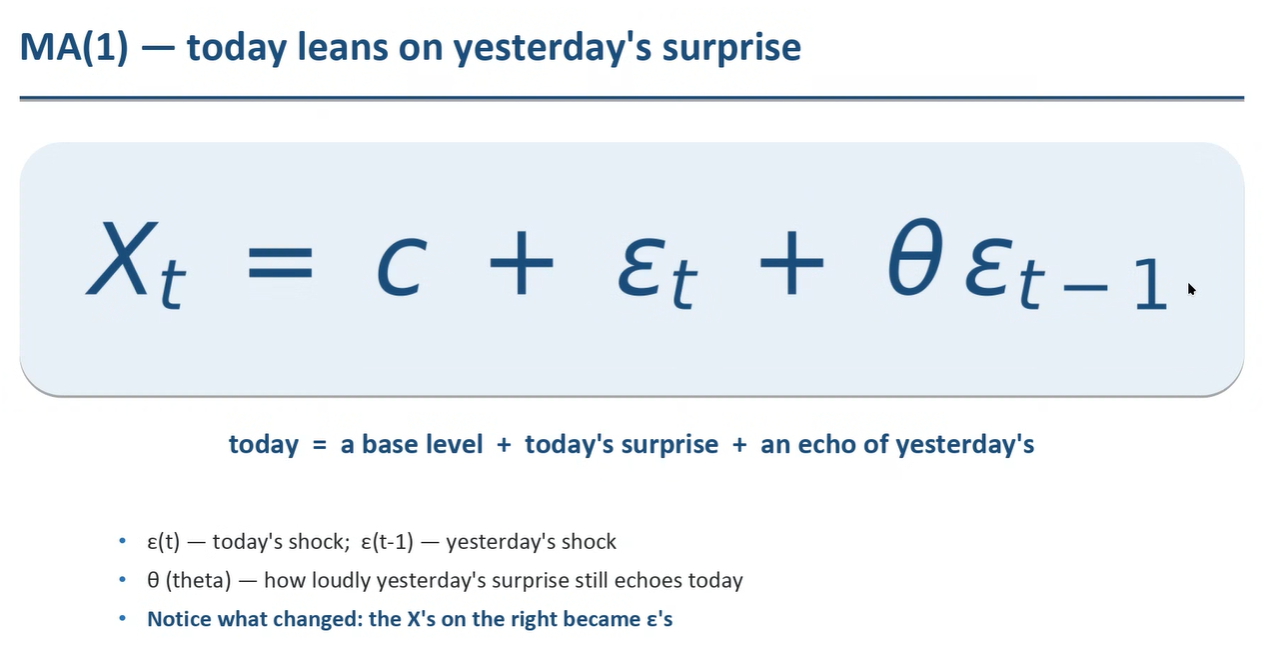

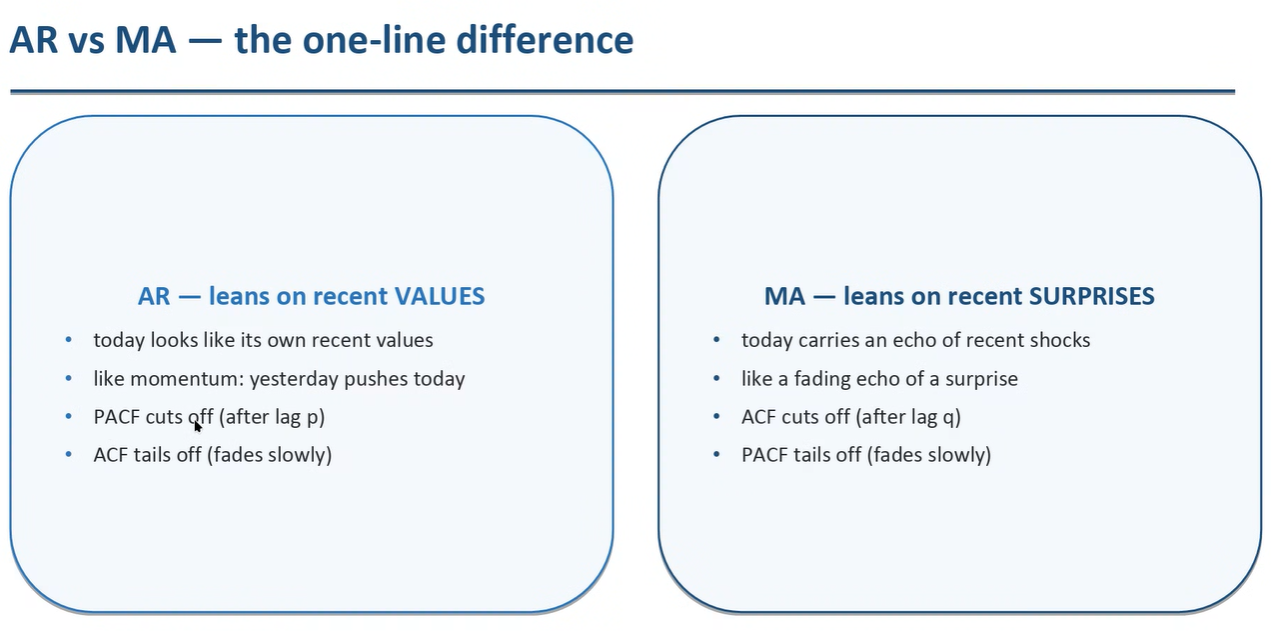

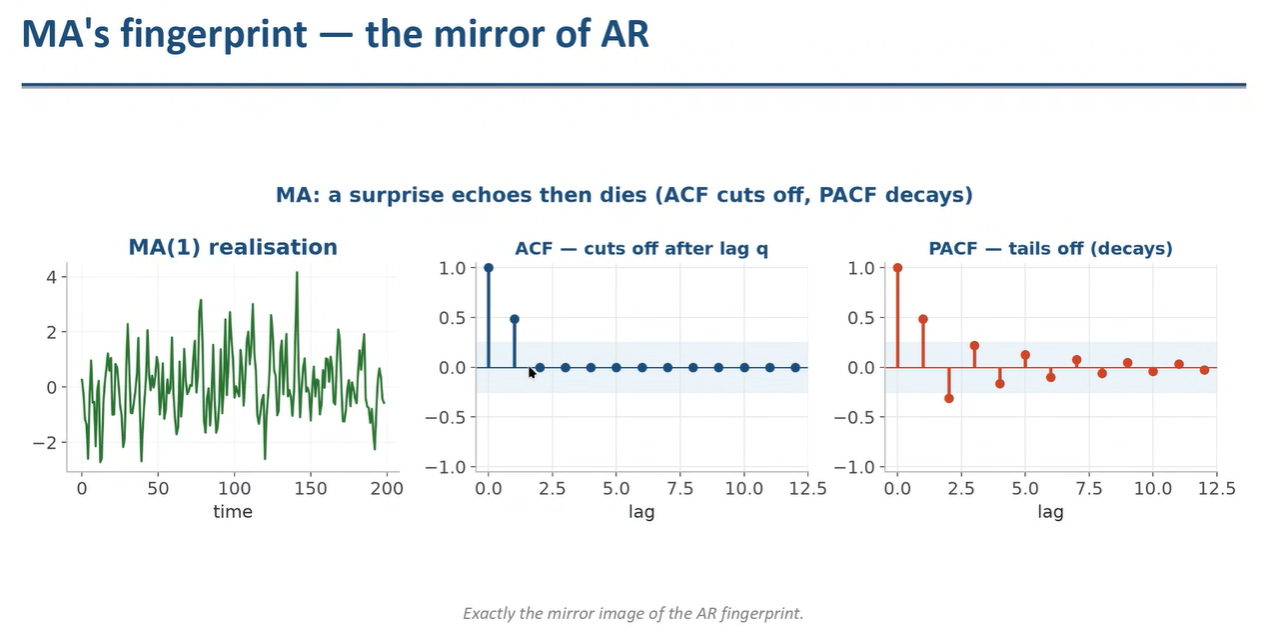

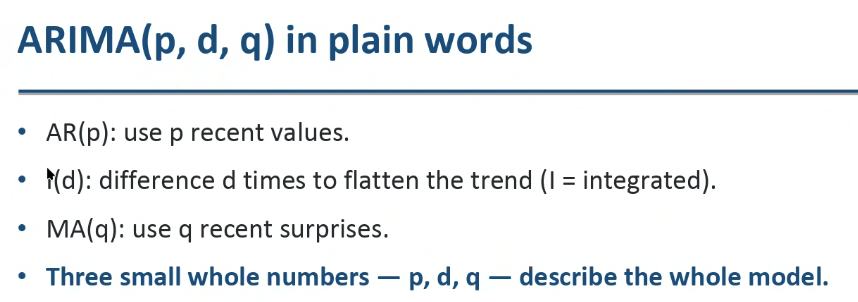

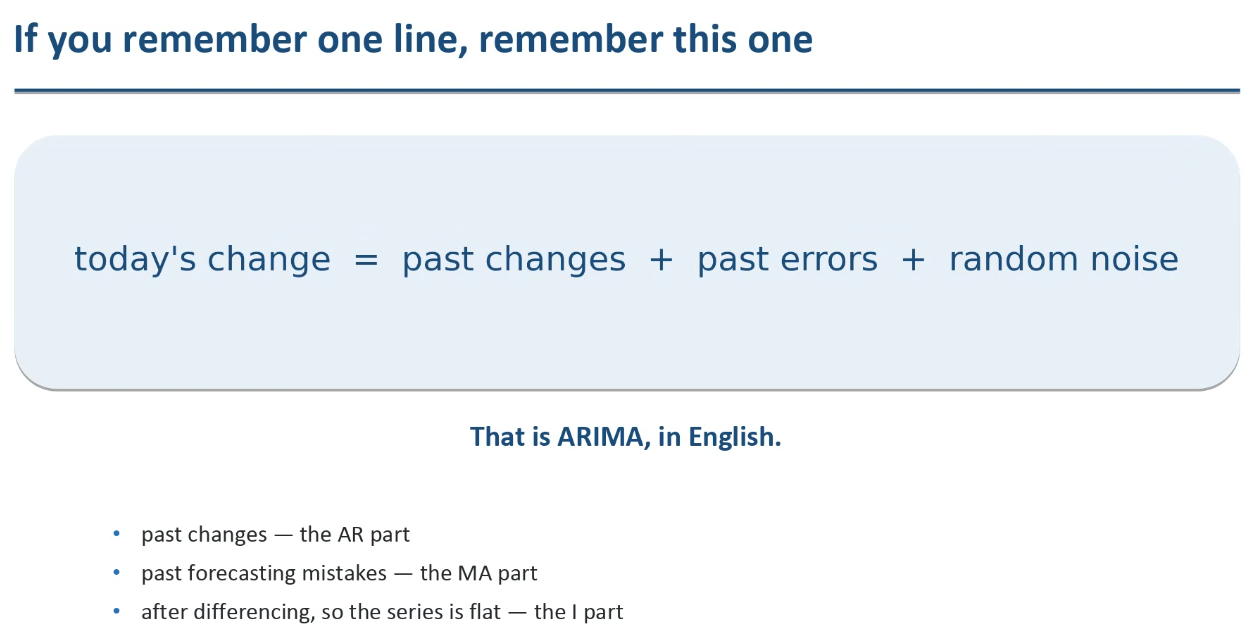

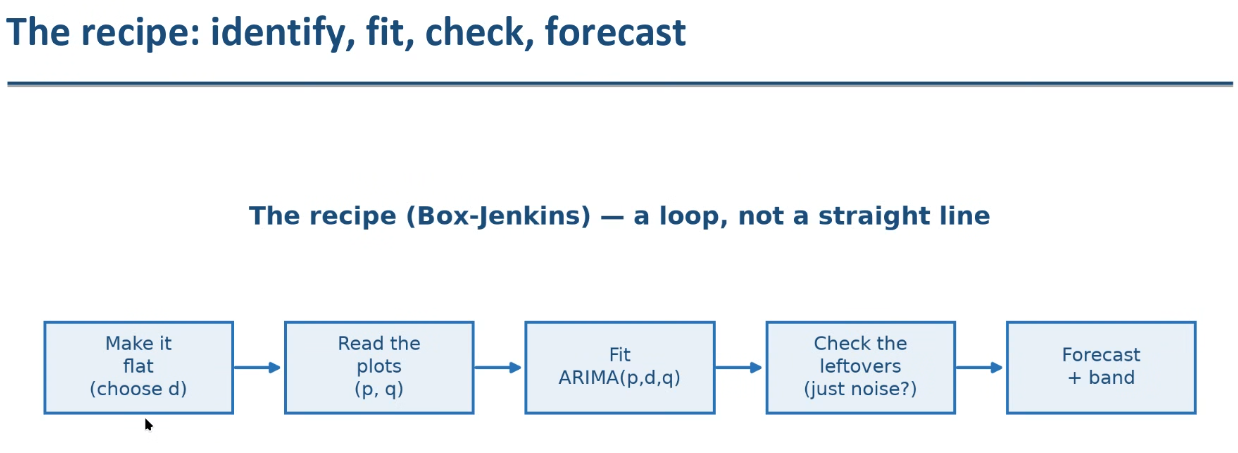

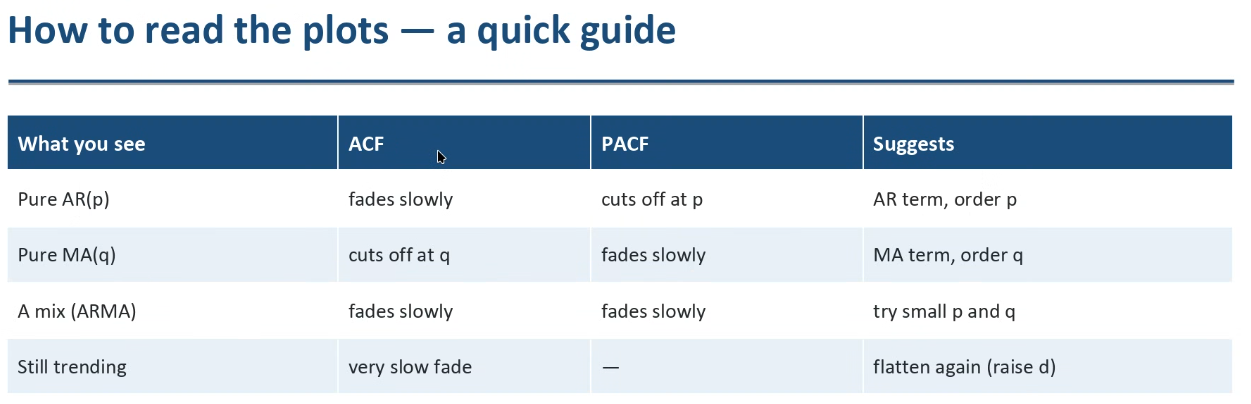

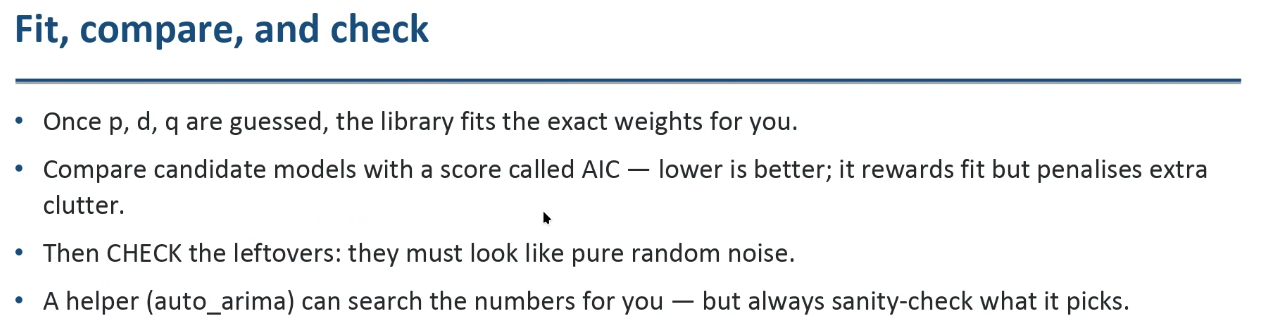

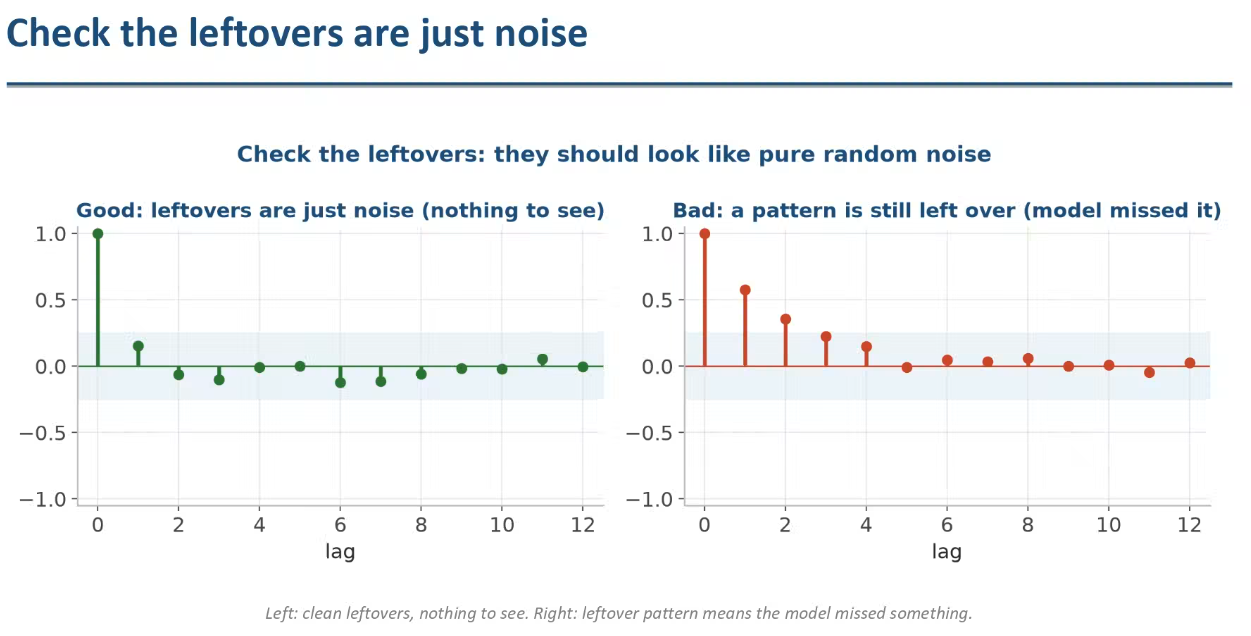

In [38]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 23.9 MB/s eta 0:00:00


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima

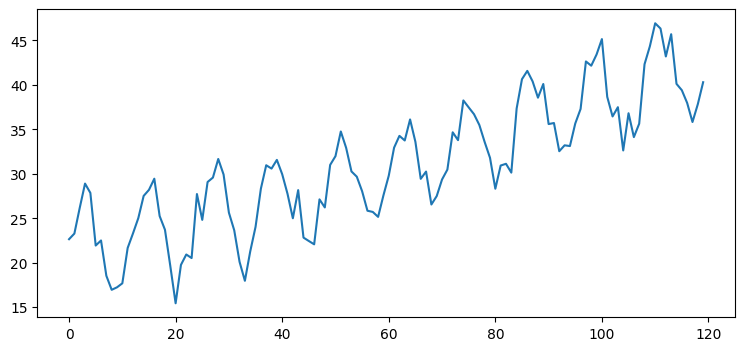

In [31]:
#Generate the data
np.random.seed(0)
#120 time steps thought of as 120 months
number_of_months = 120
time = np.arange(number_of_months)

# The three ingredients, added together
trend = 20 + 0.18 * time  #slow upward drift
season = 5 * np.sin(2 * np.pi * time / 12) #repeats every 12 months
noise = np.random.normal(0,1.5,number_of_months) #random wobble

monthly_sales = trend + season + noise

plt.figure(figsize=(9,4))
plt.plot(time, monthly_sales)

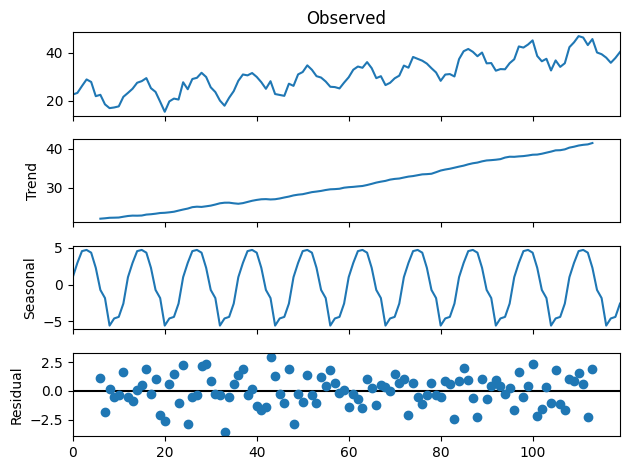

In [32]:
parts = seasonal_decompose(monthly_sales, period=12)
parts.plot()
plt.show()

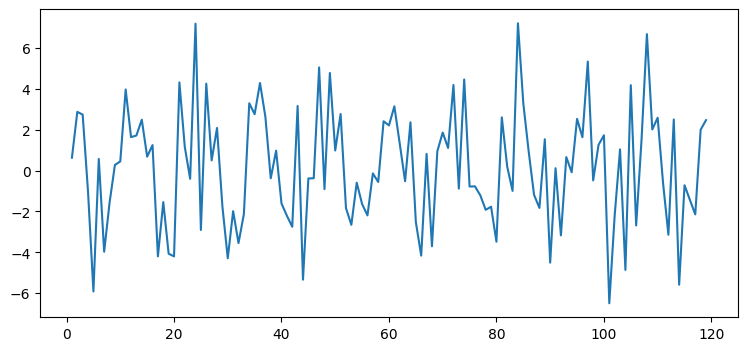

In [33]:
series = pd.Series(monthly_sales, index=time)
differenced = series.diff().dropna()
plt.figure(figsize=(9,4))
plt.plot(differenced)

In [34]:
adf_on_original = adfuller(series)
adf_on_differenced = adfuller (differenced)
print(f"Original: {adf_on_original[1]}")
print(f"Differenced: {adf_on_differenced[1]}")

Original: 0.9989533600120402
Differenced: 6.372451106589276e-12


In [35]:
arima_model = ARIMA(series, order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -293.579
Date:                Sat, 05 Sep 2026   AIC                            593.157
Time:                        12:21:23   BIC                            601.495
Sample:                             0   HQIC                           596.543
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4396      0.754      0.583      0.560      -1.038       1.917
ma.L1         -0.3424      0.792     -0.432      0.666      -1.895       1.211
sigma2         8.1343      1.139      7.139      0.0

In [41]:
model = auto_arima(series, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=538.428, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=592.224, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=593.898, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=594.000, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=590.543, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=582.151, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=591.487, Time=0.11 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=493.991, Time=0.61 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=590.674, Time=0.19 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=480.302, Time=0.74 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=512.387, Time=0.87 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=479.814, Time=3.30 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=483.997, Time

In [43]:
model = auto_arima(series, trace=True, start_p=0, start_q=0, max_p=5, max_d=2, m=12)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=592.224, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=559.956, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=580.860, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=590.543, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=593.898, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=525.329, Time=0.50 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=580.380, Time=0.16 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=526.017, Time=0.85 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=525.702, Time=0.90 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=569.787, Time=0.44 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=526.036, Time=2.46 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=519.205, Time=0.91 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AI